In [1]:
import pandas as pd
import numpy as np

C:\Users\caden\AppData\Local\Temp\ipykernel_15136\2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Read in Dataset

In [2]:
df = pd.read_csv('Data/cleaned_dataset.csv')
df

,Unnamed: 0,fid,GEOID,COUNTYFP,NAMELSAD,median_hh_,median_h_1,CDTFA_COPR,CDTFA_CITY,CDTFA_COUN,...,NAME_x,group_0_17,group_18_34,group_35_49,group_50_up,NAME_y,below_high_school,high_school_grad,some_college_assoc,bachelors_plus
0,0,516,6001423300,1,Census Tract 4233,83450.0,33008.0,1013,Berkeley,Alameda County,...,Census Tract 4233; Alameda County; California,650,788,841,1344,Census Tract 4233; Alameda County; California,151,469,637,1501
1,1,471,6001424002,1,Census Tract 4240.02,103393.0,36279.0,1013,Berkeley,Alameda County,...,Census Tract 4240.02; Alameda County; California,578,546,636,764,Census Tract 4240.02; Alameda County; California,156,93,544,1031
2,2,469,6001423000,1,Census Tract 4230,86917.0,20998.0,1013,Berkeley,Alameda County,...,Census Tract 4230; Alameda County; California,462,1401,1078,1537,Census Tract 4230; Alameda County; California,87,107,439,2742
3,3,541,6001423400,1,Census Tract 4234,107455.0,27066.0,1013,Berkeley,Alameda County,...,Census Tract 4234; Alameda County; California,925,1697,1318,1278,Census Tract 4234; Alameda County; California,175,358,873,2574
4,4,372,6001424001,1,Census Tract 4240.01,87500.0,33040.0,1013,Berkeley,Alameda County,...,Census Tract 4240.01; Alameda County; California,685,1519,729,1067,Census Tract 4240.01; Alameda County; California,277,157,529,1774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,411,350,6075023102,75,Census Tract 231.02,46786.0,15041.0,38001,San Francisco,San Francisco County,...,Census Tract 231.02; San Francisco County; Cal...,934,643,630,1024,Census Tract 231.02; San Francisco County; Cal...,351,366,966,367
412,412,1054,6075980600,75,Census Tract 9806,136250.0,21729.0,38001,San Francisco,San Francisco County,...,Census Tract 9806; San Francisco County; Calif...,282,375,292,346,Census Tract 9806; San Francisco County; Calif...,119,128,251,437
413,413,498,6075023103,75,Census Tract 231.03,29799.0,4427.0,38001,San Francisco,San Francisco County,...,Census Tract 231.03; San Francisco County; Cal...,1671,1029,702,1143,Census Tract 231.03; San Francisco County; Cal...,585,861,691,224
414,414,1374,6075023001,75,Census Tract 230.01,95052.0,16391.0,38001,San Francisco,San Francisco County,...,Census Tract 230.01; San Francisco County; Cal...,780,1094,1306,1928,Census Tract 230.01; San Francisco County; Cal...,1161,1031,518,1213


## Clean up dataset

In [3]:
df.shape

(416, 48)

In [4]:
# Check number of rows that have nulls
print(df.iloc[:,-1].isnull().sum())

0


In [5]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])


median_hh_                                                        11
median_h_1                                                        23
acs_2024_tracts_berkeley_oakland_sf_density_pct_white_nh           1
acs_2024_tracts_berkeley_oakland_sf_density_pct_black_nh           1
acs_2024_tracts_berkeley_oakland_sf_density_pct_asian_nh           1
acs_2024_tracts_berkeley_oakland_sf_density_pct_hispanic           1
acs_2024_tracts_berkeley_oakland_sf_density_pct_poc                1
acs_2024_tracts_berkeley_oakland_sf_density_median_income         10
acs_2024_tracts_berkeley_oakland_sf_density_median_home_value     34
acs_2024_tracts_berkeley_oakland_sf_density_homeownership_rate     2
weight_supply_sum                                                  2
 Accessibility_Index                                               2
dtype: int64


In [6]:
# Dropping rows where Accessibility Index is null
df = df.dropna(subset=[' Accessibility_Index'])

In [7]:
# Filling in missing values
numeric_df = df.select_dtypes(include=['number'])
missing_val_cols = numeric_df.columns[numeric_df.isnull().any()].tolist()
for column_name in missing_val_cols:
    column_median = df[column_name].median()
    df[column_name] = df[column_name].fillna(column_median)


C:\Users\caden\AppData\Local\Temp\ipykernel_15136\1653154620.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(column_median)
C:\Users\caden\AppData\Local\Temp\ipykernel_15136\1653154620.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column_name] = df[column_name].fillna(column_median)
C:\Users\caden\AppData\Local\Temp\ipykernel_15136\1653154620.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

In [8]:
df[' Accessibility_Index'].isnull().sum()

0

## Training the model

In [9]:
df.columns

Index(['Unnamed: 0', 'fid', 'GEOID', 'COUNTYFP', 'NAMELSAD', 'median_hh_',
       'median_h_1', 'CDTFA_COPR', 'CDTFA_CITY', 'CDTFA_COUN', 'CENSUS_PLA',
       'CENSUS_GEO', 'CENSUS_P_1', 'GNIS_PLACE', 'GNIS_ID',
       'acs_2024_tracts_berkeley_oakland_sf_density_city',
       'acs_2024_tracts_berkeley_oakland_sf_density_NAME',
       'acs_2024_tracts_berkeley_oakland_sf_density_year',
       'acs_2024_tracts_berkeley_oakland_sf_density_total_pop',
       'acs_2024_tracts_berkeley_oakland_sf_density_white_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_black_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_asian_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_hispanic',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_white_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_black_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_asian_nh',
       'acs_2024_tracts_berkeley_oakland_sf_density_pct_hispanic',
       'acs_2024_tracts_ber

In [10]:
# Get features and target variables 
features = ['acs_2024_tracts_berkeley_oakland_sf_density_median_income',
            'acs_2024_tracts_berkeley_oakland_sf_density_median_home_value',
            'acs_2024_tracts_berkeley_oakland_sf_density_pop_density',
            'acs_2024_tracts_berkeley_oakland_sf_density_renter_occupied',
            'acs_2024_tracts_berkeley_oakland_sf_density_homeownership_rate',
            'group_0_17',
            'group_18_34',
            'group_35_49',
            'group_50_up',
            'acs_2024_tracts_berkeley_oakland_sf_density_pct_white_nh',
            'acs_2024_tracts_berkeley_oakland_sf_density_pct_black_nh',
            'acs_2024_tracts_berkeley_oakland_sf_density_pct_asian_nh',
            'acs_2024_tracts_berkeley_oakland_sf_density_pct_hispanic',
            'acs_2024_tracts_berkeley_oakland_sf_density_pct_poc',
            'below_high_school',
            'bachelors_plus']
X = df[features]
y_log = np.log1p(df[' Accessibility_Index'])


In [11]:
# Standardizing the features and split into training and testing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler = StandardScaler()

X_train, X_test,y_train, y_test = train_test_split(X,y_log, test_size = 0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [12]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_pred = lr.predict(X_test_scaled)

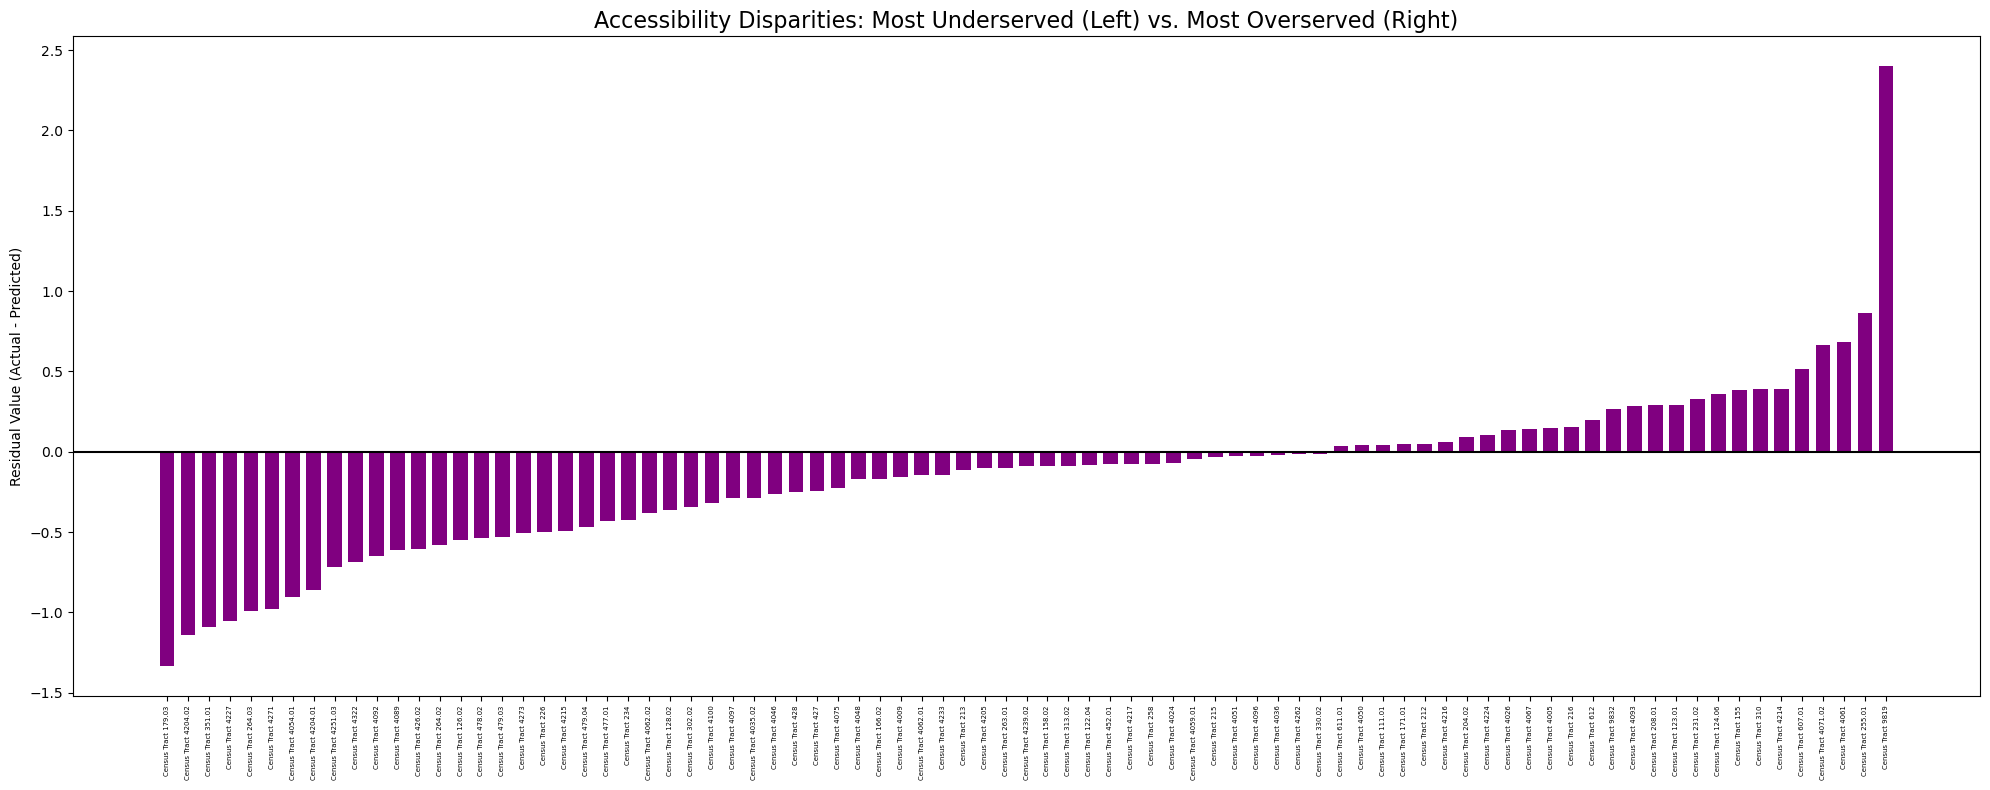

In [13]:
# Bar Chart of Residuals
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the results dataframe
# We use .copy() to avoid 'SettingWithCopyWarning'
results_df = df.loc[y_test.index,['GEOID', 'NAMELSAD']].copy()

# 2. Add the actual, predicted, and residual columns
results_df['Actual'] = y_test
results_df['Predicted'] = lr_pred
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

# 3. SORT the data
# Sorting puts the most underserved tracts on the left
results_df = results_df.sort_values(by='Residual')

# 4. Plot with extra padding
plt.figure(figsize=(20, 8))
plt.bar(results_df['NAMELSAD'], results_df['Residual'], color='purple', width=0.7)

plt.axhline(0, color='black', lw=1.5)
plt.xticks(rotation=90, fontsize=5) 

plt.title("Accessibility Disparities: Most Underserved (Left) vs. Most Overserved (Right)", fontsize=16)
plt.ylabel("Residual Value (Actual - Predicted)")
plt.tight_layout()

plt.show()

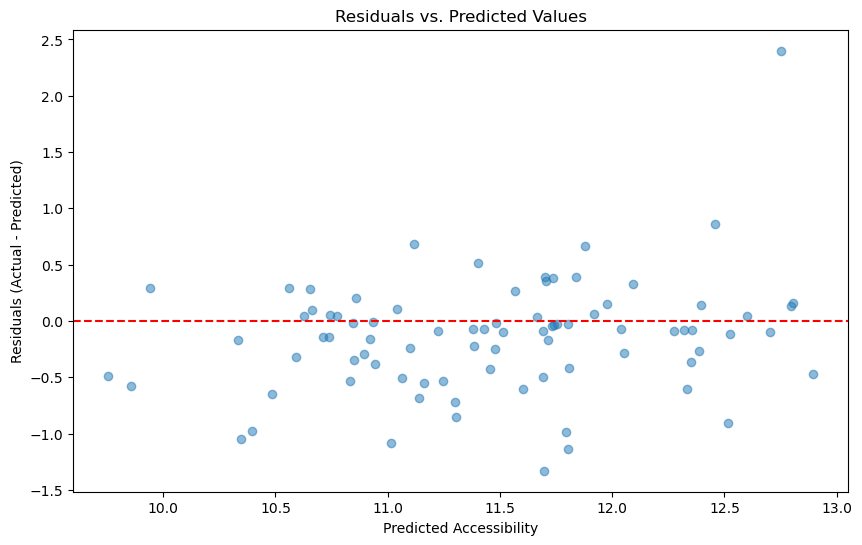

In [14]:
# Scatter plot of Residuals vs Predicted
residuals = results_df['Residual'].values
plt.figure(figsize=(10, 6))
# Plot Predicted vs Residuals
plt.scatter(lr_pred, residuals, alpha=0.5)
# Add a horizontal line at 0 (perfect prediction)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Accessibility')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values')
plt.show()

## Metrics

In [15]:
from sklearn.metrics import root_mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test,lr_pred)
r2 = r2_score(y_test,lr_pred)
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2}")

Root Mean Squared Error: 0.5318
R2 Score: 0.6243810601451544


## Cross Validation

In [16]:
from sklearn.model_selection import cross_val_score
cv_r2_scores = cross_val_score(lr,X,y_log, cv=5,scoring='r2')

print(f'Mean CV R2 scores: {cv_r2_scores.mean():.4f}')

Mean CV R2 scores: 0.5013
